In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

diabetes_130_us_hospitals = fetch_ucirepo(id=296)


c:\Users\ConnerHnatiuk\Documents\hospital-readmission-prediction-module\.venv\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [ ]:

diabetes_130_us_hospitals.data.features


In [3]:
CHARLSON_CATEGORIES = {
    "myocardial_infarction": {
        "weight": 1,
        "icd9_ranges": [(410, 412)],
        "icd9_exact": ["410", "411", "412"],
    },
    "congestive_heart_failure": {
        "weight": 1,
        "icd9_ranges": [(428, 428)],
        "icd9_prefixes": ["428"],
    },
    "peripheral_vascular_disease": {
        "weight": 1,
        "icd9_ranges": [(440, 441)],
        "icd9_prefixes": ["440", "441", "443.9", "785.4"],
        "icd9_exact": ["V43.4"],
    },
    "cerebrovascular_disease": {
        "weight": 1,
        "icd9_ranges": [(430, 438)],
        "icd9_prefixes": [],
    },
    "dementia": {
        "weight": 1,
        "icd9_ranges": [(290, 290)],
        "icd9_prefixes": ["290"],
    },
    "chronic_pulmonary_disease": {
        "weight": 1,
        "icd9_ranges": [(490, 496), (500, 505)],
        "icd9_prefixes": ["506.4"],
    },
    "rheumatic_connective_tissue": {
        "weight": 1,
        "icd9_prefixes": ["710.0", "710.1", "710.4", "714.0", "714.1", "714.2", "714.81", "725"],
        "icd9_ranges": [],
    },
    "peptic_ulcer_disease": {
        "weight": 1,
        "icd9_ranges": [(531, 534)],
        "icd9_prefixes": [],
    },
    "mild_liver_disease": {
        "weight": 1,
        "icd9_prefixes": ["571.2", "571.4", "571.5", "571.6"],
        "icd9_ranges": [],
    },
    "diabetes_no_complications": {
        "weight": 1,
        "icd9_prefixes": ["250.0", "250.1", "250.2", "250.3"],
        "icd9_ranges": [],
    },
    "diabetes_with_complications": {
        "weight": 2,
        "icd9_prefixes": ["250.4", "250.5", "250.6", "250.7", "250.8", "250.9"],
        "icd9_ranges": [],
    },
    "hemiplegia_paraplegia": {
        "weight": 2,
        "icd9_prefixes": ["342", "344.1"],
        "icd9_ranges": [(342, 342)],
    },
    "renal_disease": {
        "weight": 2,
        "icd9_prefixes": ["582", "583", "585", "586", "588"],
        "icd9_ranges": [(582, 583), (585, 586)],
        "icd9_exact": ["V42.0", "V45.1", "V56"],
    },
    "cancer_malignancy": {
        "weight": 2,
        "icd9_ranges": [(140, 172), (174, 195), (200, 208)],
        "icd9_prefixes": [],
    },
    "moderate_severe_liver_disease": {
        "weight": 3,
        "icd9_prefixes": ["572.2", "572.3", "572.4", "572.5", "572.6", "572.7", "572.8"],
        "icd9_ranges": [],
    },
    "metastatic_solid_tumor": {
        "weight": 6,
        "icd9_ranges": [(196, 199)],
        "icd9_prefixes": [],
    },
    "aids_hiv": {
        "weight": 6,
        "icd9_ranges": [(42, 44)],
        "icd9_prefixes": ["042", "043", "044"],
    },
}

In [4]:
def clean_icd9_code(code):
    """
    Clean and standardize an ICD-9 code from the UCI dataset.

    The dataset stores diagnosis codes as strings with inconsistent formats:
    - Numeric codes may have decimals or not (e.g., "428.1" or "428")
    - V-codes (supplementary) start with "V" (e.g., "V43.4")
    - E-codes (external causes) start with "E" (e.g., "E950")
    - Missing values appear as "?" or NaN
    """
    if pd.isna(code) or str(code).strip() in ("?", "", "nan", "None"):
        return None

    code = str(code).strip()
    return code


def get_numeric_prefix(code):
    """
    Extract the numeric prefix of an ICD-9 code for range matching.
    Returns the integer portion before any decimal point.
    Returns None for V-codes and E-codes (handled separately).
    """
    if code is None:
        return None

    if code.startswith(("V", "v", "E", "e")):
        return None

    try:
        # Extract the integer part before the decimal
        numeric_part = code.split(".")[0]
        return int(numeric_part)
    except (ValueError, IndexError):
        return None


def check_code_in_category(code, category_def):
    """
    Check if a single ICD-9 code falls into a Charlson category.

    Matching logic:
    1. Check exact matches first (for V-codes and special cases)
    2. Check prefix matches (e.g., "250.4" matches codes starting with "250.4")
    3. Check numeric range matches (e.g., 410-412 matches 410, 411, 412 and subcodes)
    """
    if code is None:
        return False

    # 1. Exact matches (handles V-codes, E-codes, special cases)
    exact_codes = category_def.get("icd9_exact", [])
    if code in exact_codes or code.upper() in [c.upper() for c in exact_codes]:
        return True

    # 2. Prefix matches
    prefixes = category_def.get("icd9_prefixes", [])
    for prefix in prefixes:
        if code.startswith(prefix):
            return True

    # 3. Numeric range matches
    numeric_val = get_numeric_prefix(code)
    if numeric_val is not None:
        ranges = category_def.get("icd9_ranges", [])
        for range_start, range_end in ranges:
            if range_start <= numeric_val <= range_end:
                return True

    return False

In [6]:
def compute_cci_for_codes(codes):
    """
    Compute the Charlson Comorbidity Index for a list of ICD-9 codes.

    Rules:
    - Each category is counted at most once (even if multiple codes match)
    - If both 'diabetes_no_complications' and 'diabetes_with_complications'
      are flagged, only the higher-weighted one counts
    - Same hierarchy for mild vs moderate/severe liver disease
    - Same hierarchy for cancer vs metastatic tumor
    """
    matched_categories = set()

    for code in codes:
        cleaned = clean_icd9_code(code)
        if cleaned is None:
            continue

        for category_name, category_def in CHARLSON_CATEGORIES.items():
            if check_code_in_category(cleaned, category_def):
                matched_categories.add(category_name)

    # Apply hierarchical rules:
    # If patient has complicated diabetes, remove uncomplicated
    if "diabetes_with_complications" in matched_categories:
        matched_categories.discard("diabetes_no_complications")

    # If patient has moderate/severe liver disease, remove mild
    if "moderate_severe_liver_disease" in matched_categories:
        matched_categories.discard("mild_liver_disease")

    # If patient has metastatic tumor, remove non-metastatic cancer
    if "metastatic_solid_tumor" in matched_categories:
        matched_categories.discard("cancer_malignancy")

    # Sum the weights
    total_cci = sum(
        CHARLSON_CATEGORIES[cat]["weight"] for cat in matched_categories
    )

    return total_cci, matched_categories

In [7]:
def add_cci_to_dataframe(df, diag_columns=None):
    """
    Add CCI score and individual category flags to a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        The UCI Diabetes dataset (or any DataFrame with ICD-9 diagnosis columns)
    diag_columns : list of str, optional
        Column names containing ICD-9 codes. Defaults to ['diag_1', 'diag_2', 'diag_3']

    Returns
    -------
    pd.DataFrame
        Original DataFrame with added columns:
        - 'cci_score': integer CCI score
        - 'cci_<category_name>': binary flags for each Charlson category
    """
    if diag_columns is None:
        diag_columns = ["diag_1", "diag_2", "diag_3"]

    # Verify columns exist
    missing = [col for col in diag_columns if col not in df.columns]
    if missing:
        raise ValueError(f"Columns not found in DataFrame: {missing}")

    # Compute CCI for each row
    cci_scores = []
    category_flags = {cat: [] for cat in CHARLSON_CATEGORIES}

    for _, row in df.iterrows():
        codes = [row[col] for col in diag_columns]
        score, matched = compute_cci_for_codes(codes)

        cci_scores.append(score)
        for cat in CHARLSON_CATEGORIES:
            category_flags[cat].append(1 if cat in matched else 0)

    # Add CCI score column
    df = df.copy()
    df["cci_score"] = cci_scores

    # Add individual category flag columns
    for cat in CHARLSON_CATEGORIES:
        df[f"cci_{cat}"] = category_flags[cat]

    return df

In [8]:

age_map = {
    "[0-10)": 0,
    "[10-20)": 1,
    "[20-30)": 2,
    "[30-40)": 3,
    "[40-50)": 4,
    "[50-60)": 5,
    "[60-70)": 6,
    "[70-80)": 7,
    "[80-90)": 8,
    "[90-100)": 9,
}

admission_type_map = {
    1: "emergency",
    7: "emergency",

    2: "urgent",

    3: "elective",

    4: "birth",

    5: "unknown",
    6: "unknown",
    8: "unknown"
}

discharge_disposition_map = {
    # Home
    1: "Home",
    6: "Home",
    8: "Home",

    # Transfers to hospitals / institutions
    2: "transfer",
    5: "transfer",
    9: "transfer",
    10: "transfer",
    15: "transfer",
    16: "transfer",
    17: "transfer",
    27: "transfer",
    28: "transfer",
    29: "transfer",
    30: "transfer",

    # Skilled nursing / rehab / long-term care
    3: "care_facility",
    4: "care_facility",
    22: "care_facility",
    23: "care_facility",
    24: "care_facility",

    # Hospice or death
    11: "hospice_death",
    13: "hospice_death",
    14: "hospice_death",
    19: "hospice_death",
    20: "hospice_death",
    21: "hospice_death",

    # Other / unknown
    7: "Other",
    12: "Other",
    18: "Other",
    25: "Other",
    26: "Other"
}


In [9]:
keep2 = ["age", "gender", "race", "time_in_hospital", "num_lab_procedures", "admission_source_id",
         "admission_type_id", "discharge_disposition_id",
          "number_inpatient", "number_emergency", "cci_score"]

keep = ["age", "gender", "race", "time_in_hospital", "admission_source_id", "num_lab_procedures",
          "num_procedures", "num_medications", "number_diagnoses", "admission_type_id", "discharge_disposition_id",
          "number_inpatient", "number_outpatient", "number_emergency", "cci_score", "readmitted"]

#cci = [f"cci_{key}" for key in CHARLSON_CATEGORIES.keys()]

#keep.extend(cci)
keep

['age',
 'gender',
 'race',
 'time_in_hospital',
 'admission_source_id',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_diagnoses',
 'admission_type_id',
 'discharge_disposition_id',
 'number_inpatient',
 'number_outpatient',
 'number_emergency',
 'cci_score',
 'readmitted']

In [38]:
from data_maps import admission_source_map
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np


df = diabetes_130_us_hospitals.data.features.copy()

df["readmitted"] = diabetes_130_us_hospitals.data.targets["readmitted"]

df = add_cci_to_dataframe(df)
#from comorbidipy import charlson

# Collect all diag codes per patient into a list
#df['all_diags'] = df[['diag_1', 'diag_2', 'diag_3']].apply(
#    lambda row: [c for c in row if pd.notna(c) and str(c) not in ('?', '')],
#    axis=1
#)

#df['cci_score'] = df['all_diags'].apply(
#    lambda codes: charlson(codes, icd_version=9, mapping='quan')
#)

df = df[keep].copy()

df["gender"] = df["gender"].map({"Male": 1, "Female": 0}).fillna(-1)

# Map admission type by importance
df['admission_type'] = df['admission_type_id'].map(admission_type_map).fillna("unknown")
df['admission_source'] = df['admission_source_id'].map(admission_source_map).fillna("unknown")
df['discharge_group'] = df['discharge_disposition_id'].map(discharge_disposition_map).fillna("unknown")

df = df[df["admission_type"] != "birth"]

df['age'] = df['age'].map(age_map)
df['race'] = df['race'].fillna("unknown")

# Interaction: prior utilization intensity
df["total_prior_visits"] = df["number_inpatient"] + df["number_outpatient"] + df["number_emergency"]
df["has_prior_inpatient"] = (df["number_inpatient"] > 0).astype(int)

# Medication burden relative to stay
df["meds_per_day"] = df["num_medications"] / (df["time_in_hospital"] + 1)

# Diagnosis complexity relative to stay
stay = np.where(df["time_in_hospital"] == 0, 1, df["time_in_hospital"])
df["diag_per_day"] = np.where(
    df["number_diagnoses"] == 0,
    0,
    df["number_diagnoses"] / stay
)


#df["inpatient_x_emergency"] = df["number_inpatient"] * df["number_emergency"]
#df["total_visits"] = df["number_inpatient"] + df["number_outpatient"] + df["number_emergency"]


encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_values = encoder.fit_transform(df[['race', 'discharge_group', 'admission_type', 'admission_source']])
new_cols = encoder.get_feature_names_out(['race', 'discharge_group', 'admission_type', 'admission_source'])

df_encoded = pd.DataFrame(encoded_values, columns=new_cols, index=df.index)
data_final = pd.concat([df.drop(columns=['race', 'discharge_disposition_id', 'discharge_group',
                        'admission_type_id', 'admission_type', 'admission_source', 'admission_source_id']), df_encoded], axis=1)



y = data_final["readmitted"].map({"<30": 1, ">30": 1, "NO": 0})
X = data_final.drop(columns=["readmitted"])

pd.set_option("display.max_columns", None)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X.keys()



Index(['age', 'gender', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_diagnoses',
       'number_inpatient', 'number_outpatient', 'number_emergency',
       'cci_score', 'total_prior_visits', 'has_prior_inpatient',
       'meds_per_day', 'diag_per_day', 'race_AfricanAmerican', 'race_Asian',
       'race_Caucasian', 'race_Hispanic', 'race_Other', 'race_unknown',
       'discharge_group_Home', 'discharge_group_Other',
       'discharge_group_care_facility', 'discharge_group_hospice_death',
       'discharge_group_transfer', 'admission_type_elective',
       'admission_type_emergency', 'admission_type_unknown',
       'admission_type_urgent', 'admission_source_birth',
       'admission_source_emergency', 'admission_source_legal',
       'admission_source_physician_referral', 'admission_source_transfer',
       'admission_source_unknown'],
      dtype='str')

In [109]:
data_final.to_csv("../datasets/processed_data.csv", index=False)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#clf = LogisticRegression(max_iter=1000)
#clf = RandomForestClassifier(n_estimators=500)#, class_weight="balanced")
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, classification_report
from xgboost import XGBClassifier

models = {
  "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
  "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=300, random_state=42),
  "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
  "XGBoost": XGBClassifier(scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                            n_estimators=300, eval_metric="logloss", random_state=42),
}

for name, model in models.items():
  model.fit(X_train_scaled, y_train)
  y_pred = model.predict(X_test_scaled)
  print(f"{name}: {accuracy_score(y_test, y_pred):.3f}")
  print(classification_report(y_test, y_pred))

#clf.fit(X_train_scaled, y_train)

In [18]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
  "n_estimators": [200, 400],
  "max_depth": [4, 6, 8],
  "learning_rate": [0.05, 0.1],
  "subsample": [0.8, 1.0],
}

grid = GridSearchCV(XGBClassifier(eval_metric="logloss"),
                  param_grid, scoring="roc_auc", cv=5, n_jobs=-1)
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)
best_model = grid.best_estimator_
print(best_model.score(X_test_scaled, y_test))
y_pred = best_model.predict(X_test_scaled)
print(y_pred)


{'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
0.6499606918238994
[0 0 0 ... 1 1 1]


In [ ]:
import matplotlib.pyplot as plt

importances = best_model.feature_importances_
feat_names = X.columns
sorted_idx = importances.argsort()[-15:]  # top 15

plt.barh(feat_names[sorted_idx], importances[sorted_idx])
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()


In [ ]:
best_model.score(X_test_scaled, y_test)

In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, classification_report
import seaborn as sn
y_pred = best_model.predict(X_test_scaled)

print("Classification Report")

fig, ax = plt.subplots(figsize=(6, 5))

print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
print(cm)
labels = ["YES", "NO"]
sn.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

In [39]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

base_models = [
    ('lr', LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs')),
    ('lgbm', LGBMClassifier(
        n_estimators=300, num_leaves=31, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, is_unbalance=True
    )),
    ('rf', RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight='balanced'
    )),
    #('xbg', XGBClassifier(eval_metric="logloss", learning_rate=0.05, max_depth=6, n_estimators=200, subsample=0.8))
]

stack = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5,                  # 5-fold for out-of-fold predictions
    stack_method='predict_proba',  # use probabilities, not hard labels
    passthrough=False      # only base model outputs go to meta-learner
)

stack.fit(X_train, y_train)
y_pred_proba = stack.predict_proba(X_test)[:, 1]

[LightGBM] [Info] Number of positive: 37519, number of negative: 43885
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003541 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 705
[LightGBM] [Info] Number of data points in the train set: 81404, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.460899 -> initscore=-0.156725
[LightGBM] [Info] Start training from score -0.156725
[LightGBM] [Info] Number of positive: 30015, number of negative: 35108
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002571 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 694
[LightGBM] [Info] Number of data points in the train set: 65123, number of used features: 34
[LightGBM] [Info] [b

In [107]:
import joblib

# Save the model
joblib.dump(stack, "../models/stacking_readmit_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(encoder, "../models/encoder.pkl")


['../models/encoder.pkl']

AUROC: 0.704
AUPRC: 0.668
Best threshold (by F1): 0.327
              precision    recall  f1-score   support

  No Readmit       0.76      0.34      0.47     10972
     Readmit       0.53      0.88      0.66      9380

    accuracy                           0.59     20352
   macro avg       0.65      0.61      0.57     20352
weighted avg       0.66      0.59      0.56     20352

[[3779 7193]
 [1163 8217]]


c:\Users\ConnerHnatiuk\Documents\hospital-readmission-prediction-module\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\ConnerHnatiuk\Documents\hospital-readmission-prediction-module\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ConnerHnatiuk\Documents\hospital-readmission-prediction-module\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.5889838836477987


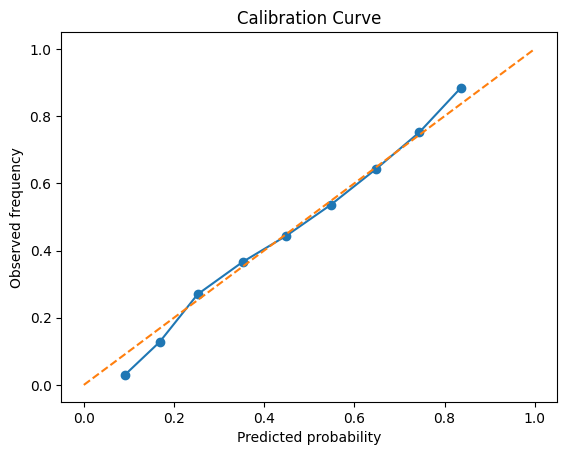

In [48]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
# Get probabilities on the held-out test set
y_proba = stack.predict_proba(X_test)[:, 1]

# Core metrics
auroc = roc_auc_score(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)
print(f"AUROC: {auroc:.3f}")
print(f"AUPRC: {auprc:.3f}")

# Find a good threshold using precision-recall trade-off
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[f1_scores.argmax()]
print(f"Best threshold (by F1): {best_threshold:.3f}")

# Confusion matrix at that threshold
y_pred = (y_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_pred, target_names=['No Readmit', 'Readmit']))
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Predicted probability')
plt.ylabel('Observed frequency')
plt.title('Calibration Curve')

print(stack.score(X_test_scaled, y_test))

Text(45.72222222222221, 0.5, 'Actual')

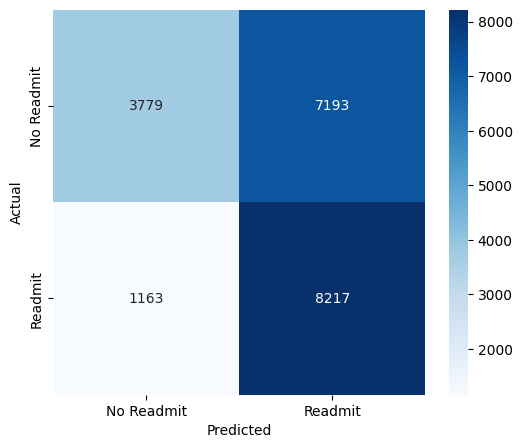

In [49]:
import matplotlib.pyplot as plt
import seaborn as sn

fig, ax = plt.subplots(figsize=(6, 5))

labels = ["No Readmit", "Readmit"]
sn.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

In [33]:
from enum import Enum
import polars as pl
import inspect
import comorbidipy

class CharlsonCategoryEnum(str, Enum):
    myocardial_infarction = "myocardial_infarction"
    congestive_heart_failure = "congestive_heart_failure"
    peripheral_vascular_disease = "peripheral_vascular_disease"
    cerebrovascular_disease = "cerebrovascular_disease"
    dementia = "dementia"
    chronic_pulmonary_disease = "chronic_pulmonary_disease"
    rheumatic_connective_tissue = "rheumatic_connective_tissue"
    peptic_ulcer_disease = "peptic_ulcer_disease"
    mild_liver_disease = "mild_liver_disease"
    diabetes_no_complications = "diabetes_no_complications"
    diabetes_with_complications = "diabetes_with_complications"
    hemiplegia_paraplegia = "hemiplegia_paraplegia"
    renal_disease = "renal_disease"
    cancer_malignancy = "cancer_malignancy"
    moderate_severe_liver_disease = "moderate_severe_liver_disease"
    metastatic_solid_tumor = "metastatic_solid_tumor"
    aids_hiv = "aids_hiv"

#print(inspect.signature(comorbidipy.comorbidity))

def _get_charlson_columns() -> list[str]:
    dummy = pl.DataFrame({
        "id": [1],
        "code": ["250.00"],
    })
    result = comorbidipy.comorbidity(
        dummy,
        id_col="id",
        code_col="code",
        score="charlson",
        icd="icd9",
        variant="quan"
    )
    exclude = {"id", "comorbidity_score", "age_adjusted_comorbidity_score", "survival_10yr"}
    return [col for col in result.columns if col not in exclude]

# Build enum dynamically from library output
_category_names = _get_charlson_columns()
CharlsonCategoryEnum = Enum(
    "CharlsonCategoryEnum",
    {name: name for name in _category_names}
)
print(_category_names)
CharlsonCategoryEnum

['aids', 'ami', 'canc', 'cevd', 'chf', 'copd', 'dementia', 'diab', 'diabwc', 'hp', 'metacanc', 'mld', 'msld', 'pud', 'pvd', 'rend', 'rheumd']


<enum 'CharlsonCategoryEnum'>